In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('creditcard.csv')[:20_000] # reading only 80,000 rows
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'creditcard.csv'

In [15]:
X = df.drop(columns=['Time', 'Amount', 'Class']).values
y = df['Class'].values
f"Shapes of X={X.shape} y={y.shape} #Fraud Cases={y.sum()}"

'Shapes of X=(80000, 28) y=(80000,) #Fraud Cases=196'

In [16]:
from sklearn.linear_model import LogisticRegression

mod = LogisticRegression(class_weight={0:1,1:2}, max_iter=1000)
mod.fit(X,y).predict(X).sum()

172

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid={'class_weight': [{0:1,1:v} for v in np.linspace(1,20,30)]},
    cv=10,
    scoring={"precision":make_scorer(precision_score), 'recall':make_scorer(recall_score)},
    refit='precision',
    return_train_score=True,
    n_jobs=-1
)
grid.fit(X,y)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'class_weight': [{0: 1, 1: 1.0}, {0: 1, 1: 1.6551724137931034}, ...]}"
,scoring,"{'precision': make_scorer(p...hod='predict'), 'recall': make_scorer(r...hod='predict')}"
,n_jobs,-1
,refit,'precision'
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [ ]:
from sklearn.metrics import precision_score, recall_score
precision_score(y, grid.predict(X))

0.7814569536423841

In [19]:
recall_score(y,grid.predict(X))

0.6020408163265306

In [23]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.237515,0.034247,0.005897,0.002740,"{0: 1, 1: 1.0}","{'class_weight': {0: 1, 1: 1.0}}",1.000000,0.463415,0.583333,1.000000,...,0.632768,0.559322,0.573864,0.573864,0.562500,0.619318,0.625000,0.602273,0.611049,0.051750
1,0.231897,0.041601,0.006679,0.002302,"{0: 1, 1: 1.6551724137931034}","{'class_weight': {0: 1, 1: 1.6551724137931034}}",1.000000,0.441860,0.583333,1.000000,...,0.689266,0.627119,0.670455,0.647727,0.630682,0.681818,0.698864,0.687500,0.681366,0.053324
2,0.245133,0.036093,0.006996,0.001584,"{0: 1, 1: 2.310344827586207}","{'class_weight': {0: 1, 1: 2.310344827586207}}",1.000000,0.431818,0.583333,1.000000,...,0.734463,0.683616,0.715909,0.693182,0.681818,0.721591,0.744318,0.727273,0.723889,0.044372
3,0.267735,0.028472,0.006750,0.003008,"{0: 1, 1: 2.9655172413793105}","{'class_weight': {0: 1, 1: 2.9655172413793105}}",1.000000,0.431818,0.583333,1.000000,...,0.779661,0.706215,0.744318,0.732955,0.715909,0.755682,0.772727,0.738636,0.749413,0.039118
4,0.234486,0.055690,0.006205,0.002422,"{0: 1, 1: 3.6206896551724137}","{'class_weight': {0: 1, 1: 3.6206896551724137}}",1.000000,0.431818,0.583333,1.000000,...,0.819209,0.734463,0.761364,0.744318,0.732955,0.778409,0.784091,0.761364,0.770939,0.035655
5,0.213353,0.026651,0.007407,0.003618,"{0: 1, 1: 4.275862068965517}","{'class_weight': {0: 1, 1: 4.275862068965517}}",1.000000,0.431818,0.583333,1.000000,...,0.841808,0.774011,0.778409,0.789773,0.784091,0.789773,0.801136,0.772727,0.794190,0.029023
6,0.222014,0.012910,0.007824,0.004288,"{0: 1, 1: 4.931034482758621}","{'class_weight': {0: 1, 1: 4.931034482758621}}",1.000000,0.431818,0.583333,1.000000,...,0.847458,0.790960,0.795455,0.818182,0.795455,0.801136,0.823864,0.795455,0.812898,0.022564
7,0.221546,0.020656,0.006944,0.003104,"{0: 1, 1: 5.586206896551724}","{'class_weight': {0: 1, 1: 5.586206896551724}}",1.000000,0.431818,0.583333,1.000000,...,0.847458,0.819209,0.829545,0.829545,0.812500,0.812500,0.829545,0.818182,0.827080,0.014785
8,0.217616,0.013928,0.006282,0.002663,"{0: 1, 1: 6.241379310344827}","{'class_weight': {0: 1, 1: 6.241379310344827}}",1.000000,0.422222,0.583333,0.947368,...,0.847458,0.830508,0.846591,0.835227,0.818182,0.829545,0.857955,0.835227,0.838996,0.013990
9,0.218834,0.021930,0.007428,0.002425,"{0: 1, 1: 6.896551724137931}","{'class_weight': {0: 1, 1: 6.896551724137931}}",0.944444,0.422222,0.583333,0.947368,...,0.847458,0.836158,0.846591,0.840909,0.829545,0.835227,0.863636,0.846591,0.845233,0.010835


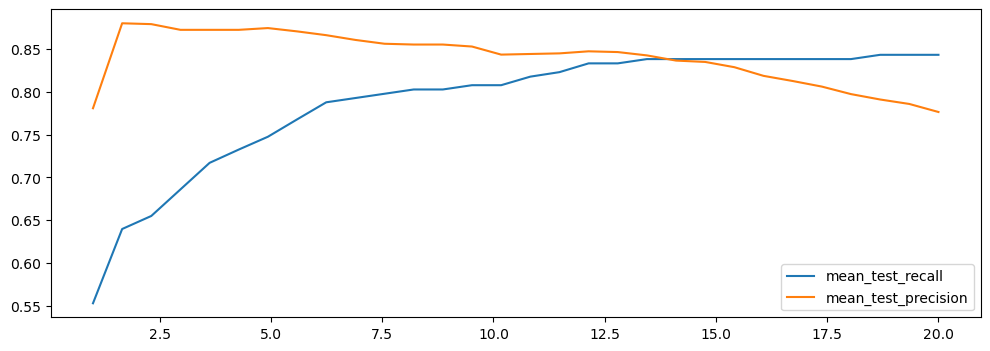

In [24]:
plt.figure(figsize=(12,4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_test_recall', 'mean_test_precision']:
    plt.plot([_[1] for _ in df['param_class_weight']],
             df[score],
             label=score)
plt.legend()

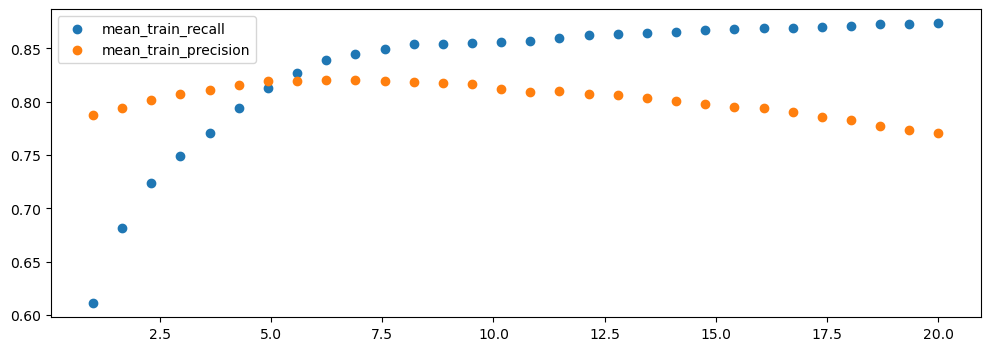

In [25]:
plt.figure(figsize=(12,4))
df = pd.DataFrame(grid.cv_results_)
for score in ['mean_train_recall', 'mean_train_precision']:
    plt.scatter([_[1] for _ in df['param_class_weight']],
             y=df[score.replace('test', 'train')],
             label=score)
plt.legend()